<a href="https://colab.research.google.com/github/sidms24/AML/blob/main/notebooks/TVAE_hp_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
if not os.path.exists('models'):
    !git clone https://github.com/sidms24/AML.git
    os.chdir('AML')
!pip install -q -r requirements.txt

Cloning into 'AML'...
remote: Enumerating objects: 585, done.
remote: Counting objects: 100% (131/131), done.
remote: Compressing objects: 100% (127/127), done.
remote: Total 585 (delta 82), reused 4 (delta 4), pack-reused 454 (from 2)
Receiving objects: 100% (585/585), 22.75 MiB | 12.28 MiB/s, done.
Resolving deltas: 100% (352/352), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.7/199.7 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.1/182.1 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.6/74.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 7.3 MB/s eta 0:00:00


In [5]:
import torch, numpy as np, pandas as pd
import optuna
from optuna.visualization.matplotlib import (
    plot_optimization_history, plot_param_importances,
    plot_slice, plot_contour,  plot_pareto_front
)
from optuna.distributions import CategoricalDistribution, FloatDistribution
from optuna.importance import get_param_importances
from copy import deepcopy
import math
import gc
import tqdm
import tqdm.auto
tqdm.auto.tqdm = tqdm.tqdm
import joblib, warnings, os
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
from scipy.stats import rankdata
from utils.dataloader import load_data, _collate_mixed
from utils.encoders import dna_one_hot
from utils.param_sweep import run_vae_sweep, run_tvae_sweep
from utils.drift import compute_drift_scores
from utils.inference import extract_latents
from utils.loss import VAE_Loss
from utils.train import VAE_train
from models import TransformerVAE, VAE
from utils.sweep_config import TVAE_FIXED
from scipy.stats import spearmanr, rankdata
import matplotlib.pyplot as plt

from datasets import load_dataset
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True

os.makedirs('results', exist_ok=True)

Device: cpu


In [ ]:
!wget https://huggingface.co/datasets/sidms/AML/resolve/main/sweep_results_tvae/optuna_study_tvae.pkl -O optuna_study_tvae.pkl
!wget https://huggingface.co/datasets/sidms/AML/resolve/main/sweep_results_tvae/optuna_study_tvae2.pkl -O optuna_study_tvae2.pkl

In [8]:
unified_dists = {
    'latent_dim': CategoricalDistribution(choices=(32, 64, 128)),
    'beta': FloatDistribution(low=1e-2, high=0.12),
    'lr': FloatDistribution(low=1.5e-4, high=4e-4),
    'dropout': CategoricalDistribution(choices=(0.0, 0.1)),
    'd_model': CategoricalDistribution(choices=(64, 128)),
    'num_layers': CategoricalDistribution(choices=(2, 3)),
    'num_memory_tokens': CategoricalDistribution(choices=(4, 8)),
}

s1 = joblib.load("optuna_study_tvae.pkl")
s2 = joblib.load("optuna_study_tvae2.pkl")

merged = optuna.create_study(directions=s1.directions, study_name="merged_tvae")

for t in s1.trials + s2.trials:
    if not all(math.isfinite(v) for v in t.values):
        continue
    merged.add_trial(
        optuna.trial.create_trial(
            params=t.params,
            distributions=unified_dists,
            values=t.values,
            state=t.state,
            user_attrs=t.user_attrs,
        )
    )

joblib.dump(merged, "results/optuna_study_tvae_merged.pkl")

['results/optuna_study_tvae_merged.pkl']

In [12]:
# results table — filter out diverged trials
rows = []
for t in merged.trials:
    if t.values[0] == float('inf'):
        continue
    beta_val = t.params.get('beta', np.nan)
    test_kl = t.user_attrs.get('test_kl', np.nan)
    test_recon = t.user_attrs.get('test_recon', t.values[0])

    rows.append({
        'trial': t.number,
        'latent_dim': t.params.get('latent_dim', t.user_attrs.get('latent_dim')),
        'beta': round(beta_val, 3) if not np.isnan(beta_val) else np.nan,
        'd_model': t.user_attrs.get('d_model', t.params.get('d_model')),
        'num_layers': t.user_attrs.get('num_layers', t.params.get('num_layers')),
        'dim_feedforward': t.user_attrs.get('dim_feedforward', t.params.get('dim_feedforward')),
        'num_memory_tokens': t.user_attrs.get('num_memory_tokens', t.params.get('num_memory_tokens')),
        'dropout': t.params.get('dropout'),
        'lr': t.params.get('lr'),
        'test_recon': round(test_recon, 4) if not np.isnan(test_recon) else np.nan,
        'silhouette': round(-t.values[1], 4),
        'test_kl': round(test_kl, 4) if not np.isnan(test_kl) else np.nan,
        'kl_collapsed': t.user_attrs.get('kl_collapsed'),
        'epochs': t.user_attrs.get('epochs_trained'),
        'test_loss': round(test_recon + beta_val * test_kl, 4)
                    if not (np.isnan(test_recon) or np.isnan(beta_val) or np.isnan(test_kl))
                    else np.nan,
    })
df_tvae2 = pd.DataFrame(rows).sort_values('test_loss')
df_tvae2.to_csv('results/optuna_tvae_results2.csv', index=False)
df_tvae2

,trial,latent_dim,beta,d_model,num_layers,dim_feedforward,num_memory_tokens,dropout,lr,test_recon,silhouette,test_kl,kl_collapsed,epochs,test_loss
17,17,128,0.029,128,3,512,8,0.1,0.000253,32.4673,-0.1215,59.4987,False,40,34.1708
3,3,128,0.039,128,3,512,8,0.0,0.000180,31.6638,-0.1090,71.8969,False,40,34.4610
20,20,128,0.022,128,3,512,8,0.0,0.000317,33.0262,-0.2317,71.0166,False,40,34.6011
15,15,128,0.045,128,3,512,8,0.0,0.000165,31.8262,-0.0295,68.9539,False,40,34.9614
5,5,128,0.058,128,2,512,8,0.0,0.000307,34.5038,-0.1913,38.0132,False,40,36.7055
1,1,32,0.021,128,2,512,4,0.1,0.000215,35.8652,-0.1869,53.6333,False,40,36.9736
21,21,128,0.058,128,3,512,8,0.0,0.000168,34.5992,-0.1518,47.9769,False,40,37.3944
19,19,128,0.034,128,3,512,8,0.0,0.000193,35.8358,-0.1854,57.1967,False,40,37.7965
13,13,128,0.063,128,3,512,8,0.1,0.000185,35.7541,-0.2010,39.2335,False,40,38.2422
2,2,128,0.075,128,2,512,8,0.1,0.000202,36.4903,-0.1565,38.8187,False,40,39.3840


In [16]:
for t in merged.best_trials:
    print(f"  #{t.number}: latent={t.params['latent_dim']}, "
          f"d_model={t.params['d_model']}, layers={t.params['num_layers']}, "
          f"mem={t.params['num_memory_tokens']}, beta={t.params['beta']:.3f}, "
          f"lr={t.params['lr']:.5f}, dropout={t.params['dropout']}, "
          f"recon={t.values[0]:.4f}, sil={-t.values[1]:.4f}, "
          f"total_loss={round(t.params['beta'],3)*t.user_attrs['test_kl']+t.values[0]:.4f}")

  #3: latent=128, d_model=128, layers=3, mem=8, beta=0.039, lr=0.00018, dropout=0.0, recon=31.6638, sil=-0.1090, total_loss=34.4678
  #15: latent=128, d_model=128, layers=3, mem=8, beta=0.045, lr=0.00017, dropout=0.0, recon=31.8262, sil=-0.0295, total_loss=34.9292


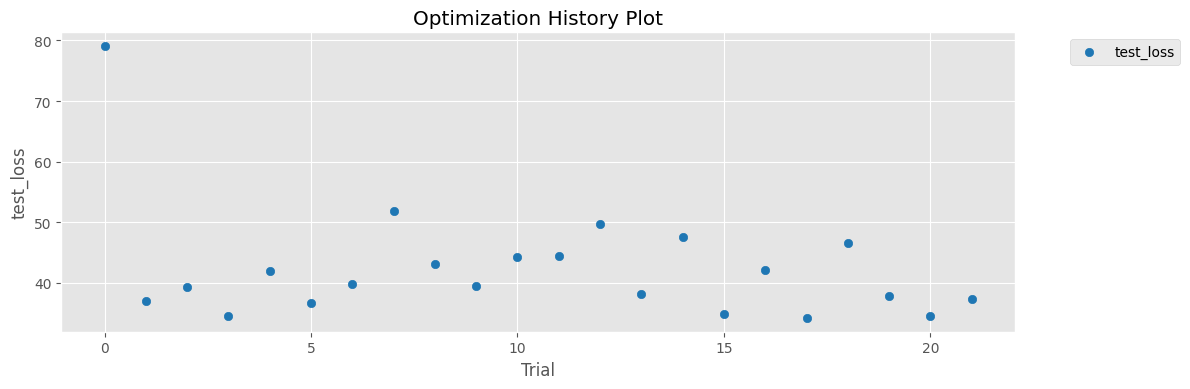

In [14]:
plot_optimization_history(merged, target=lambda t:  round(t.params['beta'], 3) * t.user_attrs['test_kl'] + t.values[0] ,
                          target_name='test_loss')
fig = plt.gcf()
fig.set_size_inches(12, 4)
plt.savefig('results/tvae_history.png', dpi=150, bbox_inches='tight')

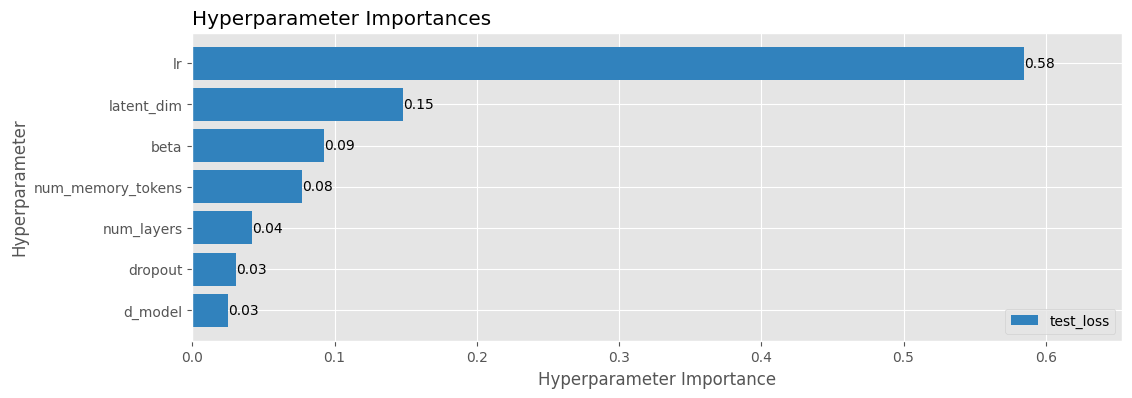

In [15]:
plot_param_importances(merged, target=lambda t: round(t.params['beta'], 3) * t.user_attrs['test_kl'] + t.values[0], target_name='test_loss')
fig = plt.gcf()
fig.set_size_inches(12, 4)
plt.savefig('results/tvae_param_importances.png', dpi=150, bbox_inches='tight')

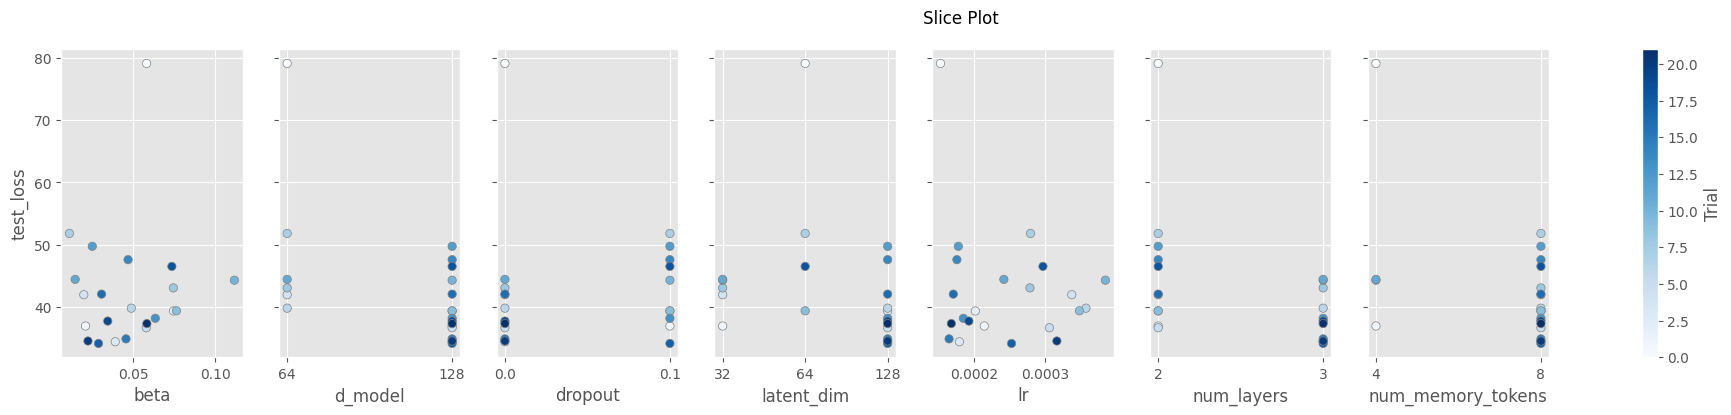

In [18]:
plot_slice(merged, params=['latent_dim', 'beta', 'd_model', 'num_layers', 'num_memory_tokens', 'lr', 'dropout'],
           target=lambda t: round(t.params['beta'], 3) * t.user_attrs['test_kl'] + t.values[0], target_name='test_loss')
fig = plt.gcf()
fig.set_size_inches(24, 4)
plt.savefig('results/tvae_slice.png', dpi=150, bbox_inches='tight')

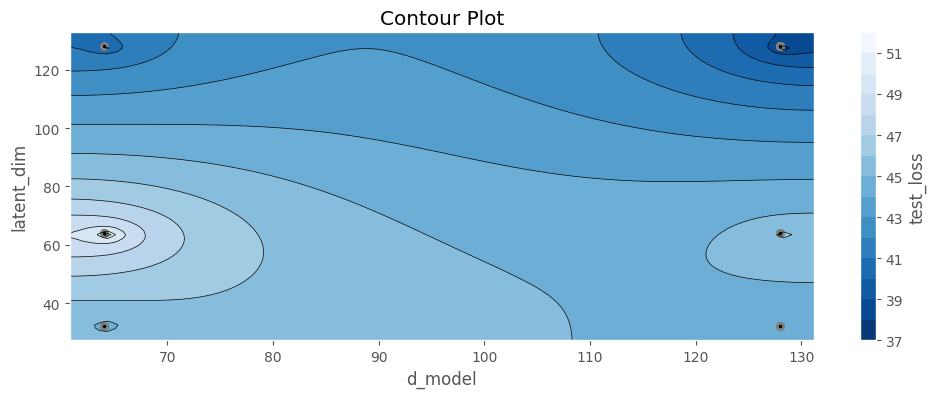

In [19]:
plot_contour(merged, params=['d_model', 'latent_dim'],
             target=lambda t: round(t.params['beta'], 3) * t.user_attrs['test_kl'] + t.values[0], target_name='test_loss')
fig = plt.gcf()
fig.set_size_inches(12, 4)
plt.savefig('results/tvae_contour.png', dpi=150, bbox_inches='tight')

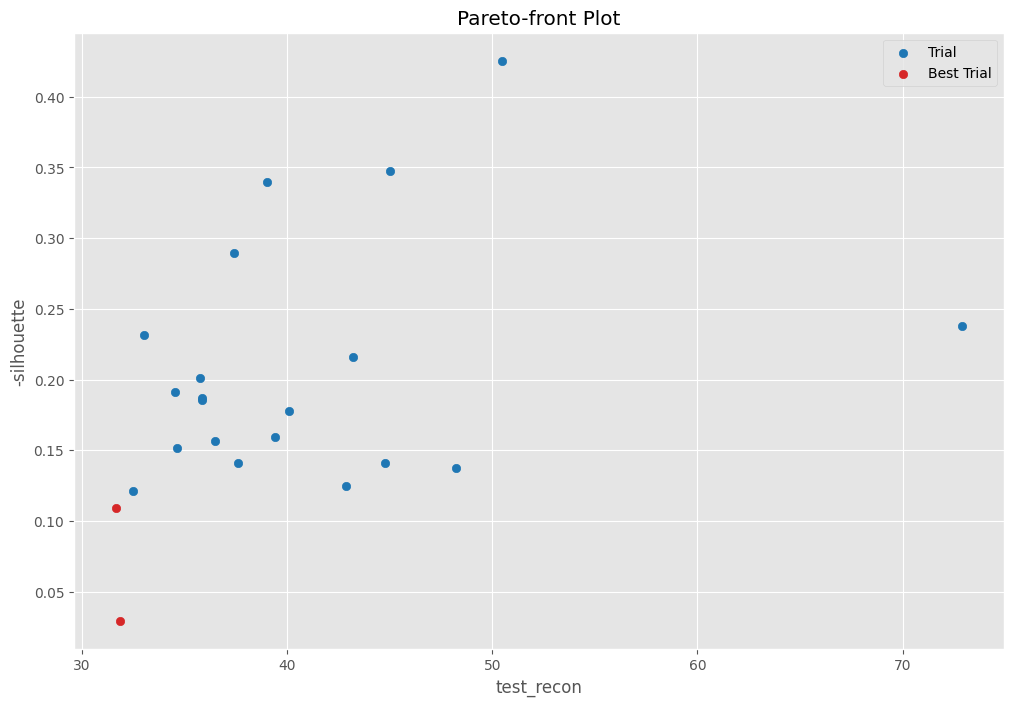

In [20]:
plot_pareto_front(merged, target_names=['test_recon', '-silhouette'])
fig = plt.gcf()
fig.set_size_inches(12, 8)
plt.savefig('results/vae_pareto.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
valid_trials = [t for t in merged.trials if t.values[0] != float('inf')]
sorted_by_tLoss = sorted(valid_trials, key=lambda t: round(t.params['beta'], 3) * t.user_attrs['test_kl'] + t.values[0])
best_trial = sorted_by_tLoss[0]
worst_trial = sorted_by_tLoss[-1]

def extract_config(t):
    return {k: t.params[k] for k in ['latent_dim', 'beta', 'd_model', 'num_layers', 'num_memory_tokens', 'lr', 'dropout']}

configs = {
    'best':  extract_config(best_trial),
    'worst': extract_config(worst_trial),
}
print('Best config: ', configs['best'])
print('Worst config:', configs['worst'])

Best config:  {'latent_dim': 128, 'beta': 0.028630640852697415, 'd_model': 128, 'num_layers': 3, 'num_memory_tokens': 8, 'lr': 0.0002532556033608517, 'dropout': 0.1}
Worst config: {'latent_dim': 64, 'beta': 0.058094985386619696, 'd_model': 64, 'num_layers': 2, 'num_memory_tokens': 4, 'lr': 0.00015305926024417372, 'dropout': 0.0}
